# 1. Imports and Configuration
Here we load the necessary libraries and define our global configuration variables.

In [1]:
import os
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Configuration
img_rows, img_cols = 224, 224
num_classes = 7
batch_size = 32
epochs = 35

train_data_dir = "../data/train"
validation_data_dir = "../data/val"

# 2. Data Preparation
We use ImageDataGenerator to load images from the directory and apply data augmentation (rotation, shifts, flips) to the training set to prevent overfitting.

In [2]:
# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling only for validation
validation_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# 3. Model Architecture
We will load the MobileNet model pre-trained on ImageNet (excluding the top layers) and add our own custom Fully Connected (Dense) layers for emotion classification.

In [3]:
mobile_net = MobileNet(weights='imagenet',include_top=False,input_shape=(img_rows, img_cols, 3))

# Define the Custom Head (Top Model)
def add_top_model(bottom_model, num_classes):
    """Creates the top or head of the model that will be
    placed on top of the bottom layers"""

    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)

    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(512, activation='relu')(top_model)

    top_model = Dense(num_classes, activation='softmax')(top_model)

    return top_model

# Assemble the model
FC_Head = add_top_model(mobile_net, num_classes)
model = Model(inputs=mobile_net.input, outputs=FC_Head)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,856,455 (22.34 MB)

 Trainable params: 5,834,567 (22.26 MB)

 Non-trainable params: 21,888 (85.50 KB)

None


# 4. Layer Freezing/Unfreezing
Here we decide which layers to train. In your original script, you set everything to True.

Note: In Transfer Learning, it is often better to freeze the base layers first, train the head, and then unfreeze layers for fine-tuning. Currently, the code below unfreezes all layers.

In [4]:
# Lock or Unlock layers for training
for layer in mobile_net.layers:
    layer.trainable = True

# Print layer status (Optional: Comment out if output is too long)
for (i, layer) in enumerate(mobile_net.layers):
    print(f"{i} {layer.__class__.__name__} Trainable: {layer.trainable}")

0 InputLayer Trainable: True
1 Conv2D Trainable: True
2 BatchNormalization Trainable: True
3 ReLU Trainable: True
4 DepthwiseConv2D Trainable: True
5 BatchNormalization Trainable: True
6 ReLU Trainable: True
7 Conv2D Trainable: True
8 BatchNormalization Trainable: True
9 ReLU Trainable: True
10 ZeroPadding2D Trainable: True
11 DepthwiseConv2D Trainable: True
12 BatchNormalization Trainable: True
13 ReLU Trainable: True
14 Conv2D Trainable: True
15 BatchNormalization Trainable: True
16 ReLU Trainable: True
17 DepthwiseConv2D Trainable: True
18 BatchNormalization Trainable: True
19 ReLU Trainable: True
20 Conv2D Trainable: True
21 BatchNormalization Trainable: True
22 ReLU Trainable: True
23 ZeroPadding2D Trainable: True
24 DepthwiseConv2D Trainable: True
25 BatchNormalization Trainable: True
26 ReLU Trainable: True
27 Conv2D Trainable: True
28 BatchNormalization Trainable: True
29 ReLU Trainable: True
30 DepthwiseConv2D Trainable: True
31 BatchNormalization Trainable: True
32 ReLU Train

# 5. Callbacks and Compilation
We define our callbacks for saving the best model, stopping early if validation loss increases, and reducing the learning rate when learning stagnates.

In [5]:
checkpoint = ModelCheckpoint(
    '../work_dirs/emotion_face_mobilNet.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', # Note: Changed 'val_acc' to 'val_accuracy' for TF 2.x
    patience=5,
    verbose=1,
    factor=0.2,
    min_lr=0.0001
)

callbacks = [earlystop, checkpoint, learning_rate_reduction]

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001), # Note: 'lr' renamed to 'learning_rate' in newer Adam
    metrics=['accuracy']
)

# 6. Training

In [6]:
# Calculate step sizes based on sample counts
nb_train_samples = train_generator.samples
nb_validation_samples = validation_generator.samples

steps_per_epoch = nb_train_samples // batch_size
validation_steps = nb_validation_samples // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

C:\Users\Supreme Leader David\Documents\GitHub\Emotion-Detection-Project\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4127 - loss: 1.5449

C:\Users\Supreme Leader David\Documents\GitHub\Emotion-Detection-Project\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.26349, saving model to ../work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 1140s 1s/step - accuracy: 0.4127 - loss: 1.5447 - val_accuracy: 0.5375 - val_loss: 1.2635 - learning_rate: 0.0010
Epoch 2/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 16:32 1s/step - accuracy: 0.3750 - loss: 1.7324

...

897/897 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.5625 - loss: 1.1485 - val_accuracy: 0.6360 - val_loss: 0.9570 - learning_rate: 0.0010
Epoch 15/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6390 - loss: 0.9661
Epoch 15: val_loss did not improve from 0.95699
897/897 ━━━━━━━━━━━━━━━━━━━━ 1068s 1s/step - accuracy: 0.6390 - loss: 0.9661 - val_accuracy: 0.6430 - val_loss: 0.9678 - learning_rate: 0.0010
Epoch 16/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 16:23 1s/step - accuracy: 0.6562 - loss: 0.8922
Epoch 16: val_loss did not improve from 0.95699
897/897 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.6562 - loss: 0.8922 - val_accuracy: 0.6415 - val_loss: 0.9712 - learning_rate: 0.0010
Epoch 17/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6463 - loss: 0.9512
Epoch 17: val_loss did not improve from 0.95699
897/897 ━━━━━━━━━━━━━━━━━━━━ 1088s 1s/step - accuracy: 0.6463 - loss: 0.9512 - val_accuracy: 0.6327 - val_loss: 0.9985 - learning_rate: 0.0010
Epoch 18/25
  1/897 ━━━

897/897 ━━━━━━━━━━━━━━━━━━━━ 1090s 1s/step - accuracy: 0.6552 - loss: 0.9246 - val_accuracy: 0.6480 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 20/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 16:08 1s/step - accuracy: 0.6250 - loss: 0.8961
Epoch 20: val_loss did not improve from 0.94368
897/897 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.6250 - loss: 0.8961 - val_accuracy: 0.6472 - val_loss: 0.9440 - learning_rate: 0.0010
Epoch 21/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6587 - loss: 0.9141
Epoch 21: val_loss did not improve from 0.94368
897/897 ━━━━━━━━━━━━━━━━━━━━ 1056s 1s/step - accuracy: 0.6587 - loss: 0.9141 - val_accuracy: 0.6459 - val_loss: 0.9609 - learning_rate: 0.0010
Epoch 22/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 16:11 1s/step - accuracy: 0.8125 - loss: 0.6306
Epoch 22: val_loss did not improve from 0.94368
897/897 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.8125 - loss: 0.6306 - val_accuracy: 0.6455 - val_loss: 0.9590 - learning_rate: 0.0010
Epoch 23/25
897/897 

897/897 ━━━━━━━━━━━━━━━━━━━━ 1092s 1s/step - accuracy: 0.6689 - loss: 0.8939 - val_accuracy: 0.6542 - val_loss: 0.9388 - learning_rate: 0.0010
Epoch 24/25
  1/897 ━━━━━━━━━━━━━━━━━━━━ 17:32 1s/step - accuracy: 0.6875 - loss: 0.9966
Epoch 24: val_loss improved from 0.93884 to 0.93876, saving model to ../work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.6875 - loss: 0.9966 - val_accuracy: 0.6526 - val_loss: 0.9388 - learning_rate: 0.0010
Epoch 25/25
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6731 - loss: 0.8758
Epoch 25: val_loss improved from 0.93876 to 0.92312, saving model to ../work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 1093s 1s/step - accuracy: 0.6731 - loss: 0.8758 - val_accuracy: 0.6599 - val_loss: 0.9231 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 25.


# 7. Visualization

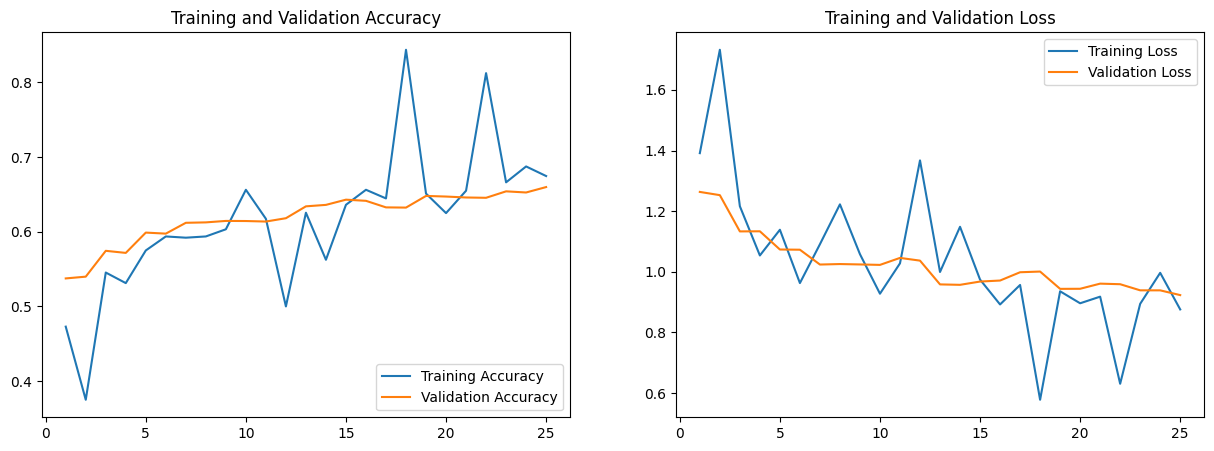

In [7]:
import matplotlib.pyplot as plt

# 1. Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# 2. Plot Accuracy
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# 3. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# 4. Save the graph to a file
plt.savefig('training_history_graph.png')
plt.show()

Found 7178 images belonging to 7 classes.
Generating predictions... (this may take a moment)


C:\Users\Supreme Leader David\Documents\GitHub\Emotion-Detection-Project\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 223ms/step


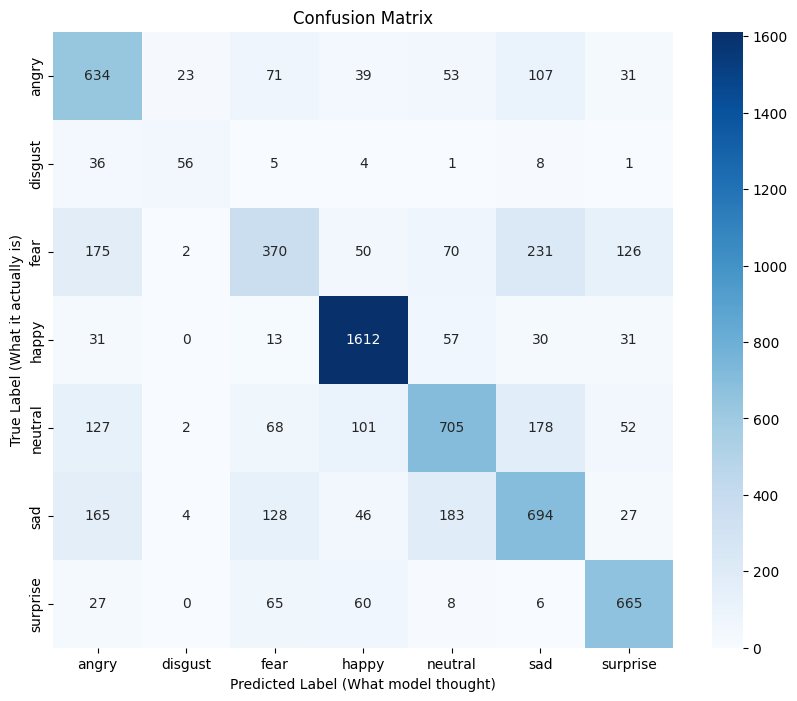


=== Classification Report ===
              precision    recall  f1-score   support

       angry       0.53      0.66      0.59       958
     disgust       0.64      0.50      0.57       111
        fear       0.51      0.36      0.42      1024
       happy       0.84      0.91      0.87      1774
     neutral       0.65      0.57      0.61      1233
         sad       0.55      0.56      0.55      1247
    surprise       0.71      0.80      0.75       831

    accuracy                           0.66      7178
   macro avg       0.64      0.62      0.62      7178
weighted avg       0.65      0.66      0.65      7178



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Re-create the validation generator with shuffle=False
# (Crucial for aligning predictions with correct labels)
validation_generator_eval = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # <--- IMPORTANT!
)

# 2. Generate Predictions
Y_pred = model.predict(validation_generator_eval, validation_generator_eval.samples // batch_size + 1)
y_pred = np.argmax(Y_pred, axis=1)

# 3. Get True Labels
# We take only as many labels as we have predictions (handles potential batch size rounding)
y_true = validation_generator_eval.classes[:len(y_pred)]

# 4. Create the Confusion Matrix
class_labels = list(validation_generator_eval.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

# 5. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.ylabel('True Label (What it actually is)')
plt.xlabel('Predicted Label (What model thought)')
plt.show()

# 6. Print Classification Report (Precision, Recall, F1-Score)
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))